In [1]:
import os
import time
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score,precision_score, recall_score,f1_score,roc_auc_score,average_precision_score, classification_report,confusion_matrix,ConfusionMatrixDisplay)

# Imbalanced Learning
from imblearn.under_sampling import RandomUnderSampler

In [2]:
# Load Dataset
df = pd.read_csv(r'D:\Data_D\TMU\MRP\1.0.Dataset\Final_Crime_Dataset.csv')
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)

(7970658, 28)
['Primary Type', 'Description', 'Location Description', 'Domestic', 'Beat', 'District', 'community_area', 'FBI Code', 'year', 'Latitude', 'Longitude', 'month', 'day_of_week', 'hour', 'per_capita_income', 'unemployment_rate', 'no_highschool_pct', 'date', 'TMAX', 'TMIN', 'PRCP', 'AWND', 'temp_avg', 'bus', 'rail_boardings', 'total_rides', 'day', 'Arrest']
Primary Type              int64
Description               int64
Location Description      int64
Domestic                  int64
Beat                      int64
District                float64
community_area            int64
FBI Code                  int64
year                      int64
Latitude                float64
Longitude               float64
month                     int64
day_of_week               int64
hour                      int64
per_capita_income       float64
unemployment_rate       float64
no_highschool_pct       float64
date                      int64
TMAX                      int64
TMIN                   

In [3]:
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [3]:
print(df["Arrest"].value_counts())
print(round(df["Arrest"].value_counts(normalize=True) * 100, 2))

Arrest
0    5913853
1    2056805
Name: count, dtype: int64
Arrest
0    74.2
1    25.8
Name: proportion, dtype: float64


In [4]:
# Split Features and Target
X = df.drop("Arrest", axis=1)
y = df["Arrest"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (7970658, 27)
Target Shape  : (7970658,)


In [5]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,stratify=y,random_state=42)
print(f"X_train Shape : {X_train.shape}")
print(f"X_test Shape  : {X_test.shape}")

print(f"y_train Shape : {y_train.shape}")
print(f"y_test Shape  : {y_test.shape}")

X_train Shape : (6376526, 27)
X_test Shape  : (1594132, 27)
y_train Shape : (6376526,)
y_test Shape  : (1594132,)


In [6]:
# Random Under Sampling
undersampler = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = undersampler.fit_resample(X_train,y_train)
print(y_train.value_counts())
print(y_train_under.value_counts())

print(f"\nX_train_under Shape : {X_train_under.shape}")
print(f"y_train_under Shape : {y_train_under.shape}")

Arrest
0    4731082
1    1645444
Name: count, dtype: int64
Arrest
0    1645444
1    1645444
Name: count, dtype: int64

X_train_under Shape : (3290888, 27)
y_train_under Shape : (3290888,)


In [7]:
# Label Encoding
categorical_columns = X_train_under.select_dtypes(include=["object"]).columns

label_encoders = {}
for column in categorical_columns:
    encoder = LabelEncoder()
    X_train_under[column] = encoder.fit_transform(X_train_under[column].astype(str))
    X_test[column] = encoder.transform(X_test[column].astype(str))
    label_encoders[column] = encoder

print(categorical_columns.tolist())

[]


In [8]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_under)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled Shape : {X_train_scaled.shape}")
print(f"X_test_scaled Shape  : {X_test_scaled.shape}")

X_train_scaled Shape : (3290888, 27)
X_test_scaled Shape  : (1594132, 27)


In [9]:
# Output Folders
MODEL_FOLDER = "1. Under_Sampling_Models"
RESULT_FOLDER = "1. Under_Sampling_Results"

os.makedirs(MODEL_FOLDER, exist_ok=True)
os.makedirs(RESULT_FOLDER, exist_ok=True)

In [10]:
joblib.dump(label_encoders, os.path.join(MODEL_FOLDER, "label_encoders.pkl"))
joblib.dump(scaler, os.path.join(MODEL_FOLDER, "standard_scaler.pkl"))

['1. Under_Sampling_Models\\standard_scaler.pkl']

In [11]:
# Create result List 
all_results = []

In [11]:
# Evaluation, Training, Predictions, Metrics, Classification Report, Confusion Matrix, Save Model 

def evaluate_model(
    model,
    model_name,
    X_train,
    y_train,
    X_test,
    y_test,
    model_folder=MODEL_FOLDER,
    result_folder=RESULT_FOLDER
):
    
    # Train Model
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    print(f"\nTraining Time : {training_time:.2f} seconds")

    # Prediction
    y_pred = model.predict(X_test)

    # Probability / Score Prediction
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]

    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)

    else:
        raise AttributeError(
            f"{model_name} does not support predict_proba() or decision_function()."
        )

   # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")
    print(f"PR AUC    : {pr_auc:.4f}")

   # Classification Report
    report = classification_report(y_test,y_pred,output_dict=True)
    print(classification_report(y_test, y_pred))
    report_df = pd.DataFrame(report).transpose()
    report_path = os.path.join(result_folder,f"{model_name}_Classification_Report.csv")
    report_df.to_csv(report_path)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm,index=["Actual_0","Actual_1"], columns=["Predicted_0","Predicted_1"])
    cm_path = os.path.join(result_folder,f"{model_name}_Confusion_Matrix.csv")
    cm_df.to_csv(cm_path)

    fig, ax = plt.subplots(figsize=(6,5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Arrest","Arrest"])
    disp.plot(cmap="Blues",ax=ax,colorbar=False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    figure_path = os.path.join(result_folder,f"{model_name}_Confusion_Matrix.png")
    plt.savefig(figure_path,dpi=300,bbox_inches="tight")
    plt.show()

    # Save Model
    model_path = os.path.join(model_folder,f"{model_name}.pkl")
    joblib.dump(model, model_path)
    
    # Store Results
    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc,
        "Training Time (s)": round(training_time, 2)
    }
    all_results.append(results)

    return results

# Logistic Regression


Training Time : 2.62 seconds
Accuracy  : 0.7479
Precision : 0.5092
Recall    : 0.6403
F1 Score  : 0.5673
ROC AUC   : 0.7546
PR AUC    : 0.5247
              precision    recall  f1-score   support

           0       0.86      0.79      0.82   1182771
           1       0.51      0.64      0.57    411361

    accuracy                           0.75   1594132
   macro avg       0.69      0.71      0.69   1594132
weighted avg       0.77      0.75      0.76   1594132



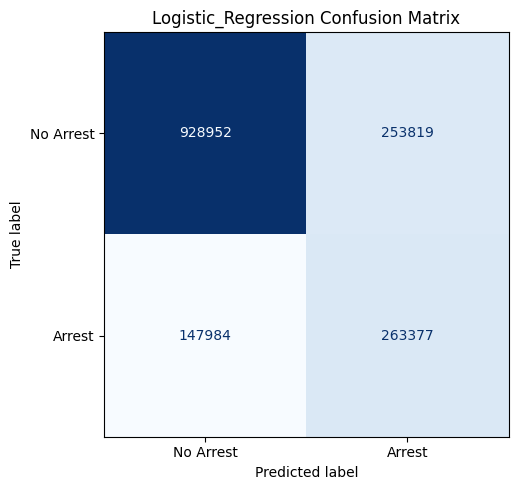

In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)

lr_results = evaluate_model(
    model=lr_model,
    model_name="Logistic_Regression",
    X_train=X_train_scaled,
    y_train=y_train_under,
    X_test=X_test_scaled,
    y_test=y_test
)

# Decision Tree


Training Time : 93.87 seconds
Accuracy  : 0.7698
Precision : 0.5372
Recall    : 0.7798
F1 Score  : 0.6361
ROC AUC   : 0.7731
PR AUC    : 0.4758
              precision    recall  f1-score   support

           0       0.91      0.77      0.83   1182771
           1       0.54      0.78      0.64    411361

    accuracy                           0.77   1594132
   macro avg       0.72      0.77      0.73   1594132
weighted avg       0.81      0.77      0.78   1594132



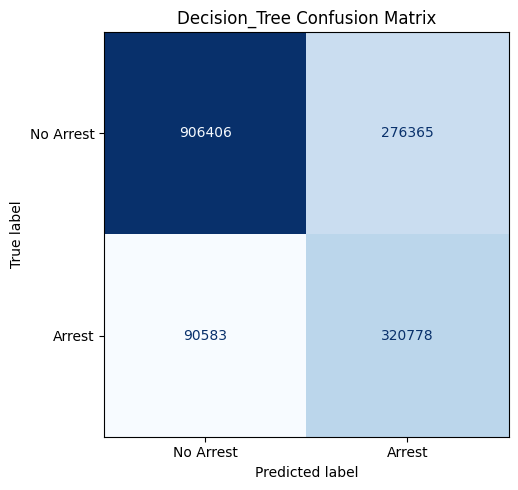

In [13]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_results = evaluate_model(
    model=dt_model,
    model_name="Decision_Tree",
    X_train=X_train_under,
    y_train=y_train_under,
    X_test=X_test,
    y_test=y_test
)

# Random Forest


Training Time : 162.06 seconds
Accuracy  : 0.8604
Precision : 0.7140
Recall    : 0.7659
F1 Score  : 0.7391
ROC AUC   : 0.9133
PR AUC    : 0.8545
              precision    recall  f1-score   support

           0       0.92      0.89      0.90   1182771
           1       0.71      0.77      0.74    411361

    accuracy                           0.86   1594132
   macro avg       0.82      0.83      0.82   1594132
weighted avg       0.86      0.86      0.86   1594132



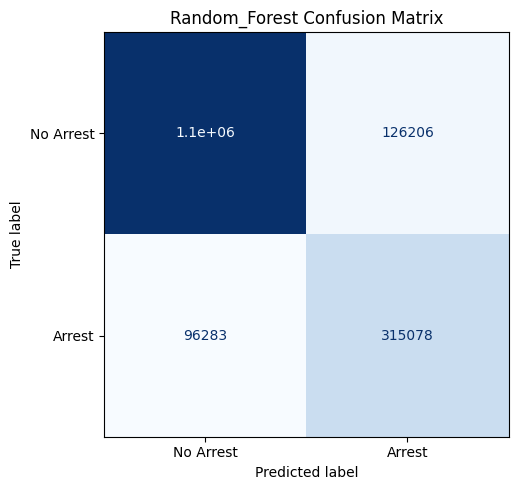

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

rf_results = evaluate_model(
    model=rf_model,
    model_name="Random_Forest",
    X_train=X_train_under,
    y_train=y_train_under,
    X_test=X_test,
    y_test=y_test
)

# Extra Trees


Training Time : 146.47 seconds
Accuracy  : 0.8533
Precision : 0.6969
Recall    : 0.7637
F1 Score  : 0.7288
ROC AUC   : 0.9070
PR AUC    : 0.8453
              precision    recall  f1-score   support

           0       0.91      0.88      0.90   1182771
           1       0.70      0.76      0.73    411361

    accuracy                           0.85   1594132
   macro avg       0.81      0.82      0.81   1594132
weighted avg       0.86      0.85      0.86   1594132



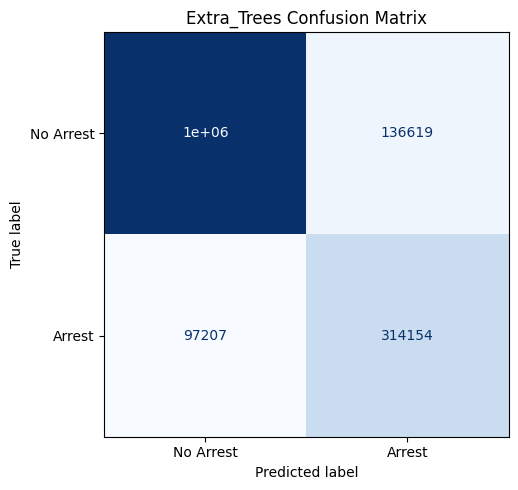

In [15]:

from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=False,
    n_jobs=-1,
    random_state=42
)

et_results = evaluate_model(
    model=et_model,
    model_name="Extra_Trees",
    X_train=X_train_under,
    y_train=y_train_under,
    X_test=X_test,
    y_test=y_test
)

# Gradient Boosting


Training Time : 1586.42 seconds
Accuracy  : 0.8628
Precision : 0.7409
Recall    : 0.7202
F1 Score  : 0.7304
ROC AUC   : 0.8990
PR AUC    : 0.8360
              precision    recall  f1-score   support

           0       0.90      0.91      0.91   1182771
           1       0.74      0.72      0.73    411361

    accuracy                           0.86   1594132
   macro avg       0.82      0.82      0.82   1594132
weighted avg       0.86      0.86      0.86   1594132



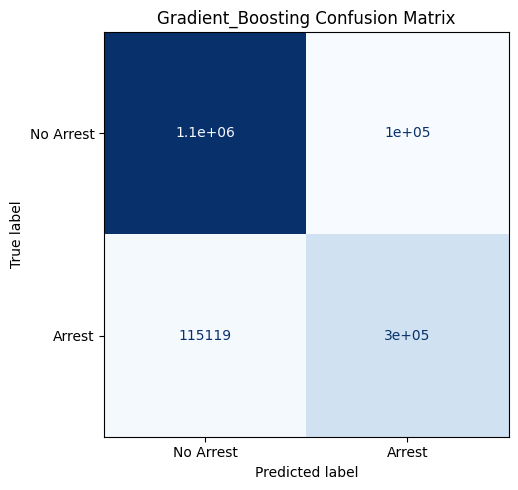

In [16]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    loss='log_loss',
    learning_rate=0.1,
    n_estimators=100,
    subsample=1.0,
    max_depth=3,
    random_state=42
)

gb_results = evaluate_model(
    model=gb_model,
    model_name="Gradient_Boosting",
    X_train=X_train_under,
    y_train=y_train_under,
    X_test=X_test,
    y_test=y_test
)

# AdaBoost


Training Time : 589.72 seconds
Accuracy  : 0.8326
Precision : 0.6721
Recall    : 0.6861
F1 Score  : 0.6790
ROC AUC   : 0.8743
PR AUC    : 0.7949
              precision    recall  f1-score   support

           0       0.89      0.88      0.89   1182771
           1       0.67      0.69      0.68    411361

    accuracy                           0.83   1594132
   macro avg       0.78      0.78      0.78   1594132
weighted avg       0.83      0.83      0.83   1594132



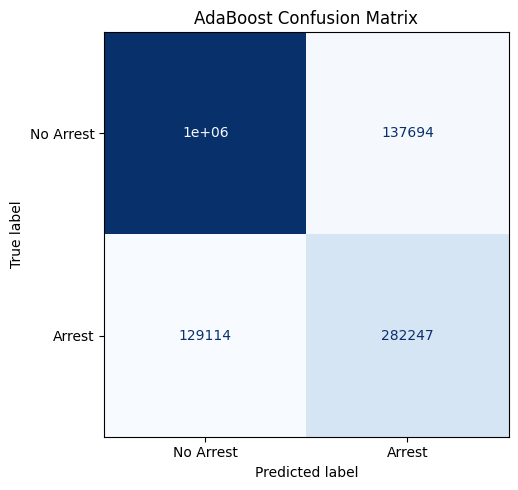

In [17]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada_results = evaluate_model(
    model=ada_model,
    model_name="AdaBoost",
    X_train=X_train_under,
    y_train=y_train_under,
    X_test=X_test,
    y_test=y_test
)

# XGBoost


Training Time : 9.85 seconds
Accuracy  : 0.8640
Precision : 0.7313
Recall    : 0.7479
F1 Score  : 0.7395
ROC AUC   : 0.9113
PR AUC    : 0.8527
              precision    recall  f1-score   support

           0       0.91      0.90      0.91   1182771
           1       0.73      0.75      0.74    411361

    accuracy                           0.86   1594132
   macro avg       0.82      0.83      0.82   1594132
weighted avg       0.87      0.86      0.86   1594132



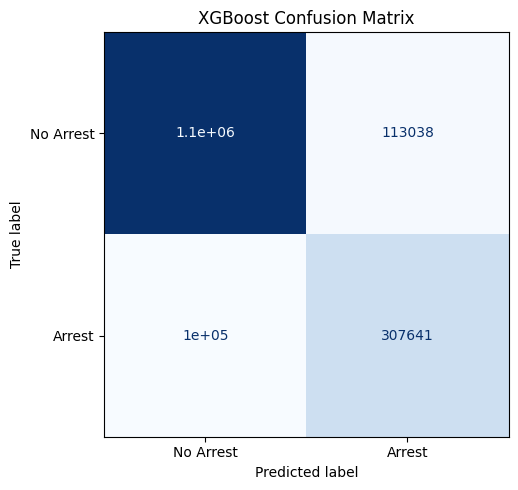

In [18]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_results = evaluate_model(
    model=xgb_model,
    model_name="XGBoost",
    X_train=X_train_under,
    y_train=y_train_under,
    X_test=X_test,
    y_test=y_test
)

# LightGBM

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1645444, number of negative: 1645444
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.122080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3500
[LightGBM] [Info] Number of data points in the train set: 3290888, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

Training Time : 9.35 seconds
Accuracy  : 0.8630
Precision : 0.7284
Recall    : 0.7479
F1 Score  : 0.7380
ROC AUC   : 0.9109
PR AUC    : 0.8520
              precision    recall  f1-score   support

           0       0.91      0.90      0.91   1182771
           1       0.73      0.75      0.74    411361

    accuracy                           0.86   1594132
   macro avg       0.82      0.83      0.82   1594132
weighted avg       0.86      0.86      0.86   1594132



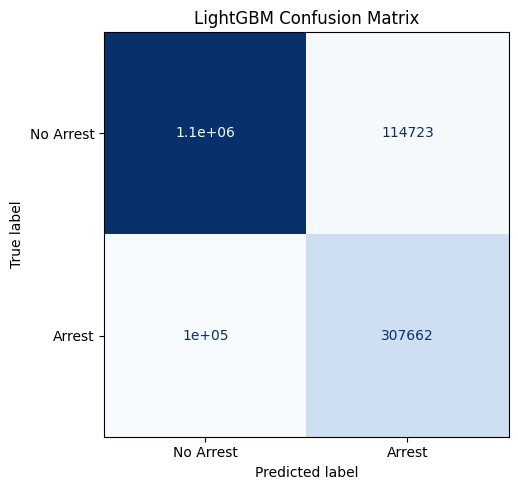

In [19]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    objective='binary',
    learning_rate=0.1,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

lgbm_results = evaluate_model(
    model=lgbm_model,
    model_name="LightGBM",
    X_train=X_train_under,
    y_train=y_train_under,
    X_test=X_test,
    y_test=y_test
)

# CatBoost


Training Time : 15.71 seconds
Accuracy  : 0.8624
Precision : 0.7318
Recall    : 0.7368
F1 Score  : 0.7343
ROC AUC   : 0.9054
PR AUC    : 0.8440
              precision    recall  f1-score   support

           0       0.91      0.91      0.91   1182771
           1       0.73      0.74      0.73    411361

    accuracy                           0.86   1594132
   macro avg       0.82      0.82      0.82   1594132
weighted avg       0.86      0.86      0.86   1594132



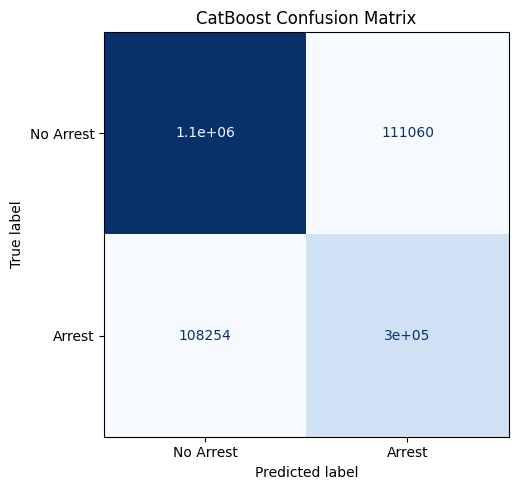

In [20]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    random_seed=42,
    verbose=0
)

cat_results = evaluate_model(
    model=cat_model,
    model_name="CatBoost",
    X_train=X_train_under,
    y_train=y_train_under,
    X_test=X_test,
    y_test=y_test
)

# Linear SVM


Training Time : 32.04 seconds
Accuracy  : 0.7478
Precision : 0.5090
Recall    : 0.6397
F1 Score  : 0.5669
ROC AUC   : 0.7539
PR AUC    : 0.5244
              precision    recall  f1-score   support

           0       0.86      0.79      0.82   1182771
           1       0.51      0.64      0.57    411361

    accuracy                           0.75   1594132
   macro avg       0.69      0.71      0.69   1594132
weighted avg       0.77      0.75      0.76   1594132



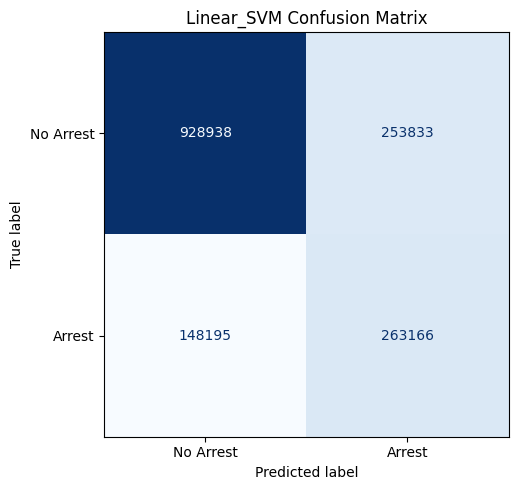

In [21]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm = LinearSVC(
    random_state=42,
    max_iter=5000   # as our dataset is large using standard SVM is not practical so sample 5000
)

# Calibrate to obtain probability estimates
svm_model = CalibratedClassifierCV(
    svm,
    method="sigmoid",
    cv=5
)

svm_results = evaluate_model(
    model=svm_model,
    model_name="Linear_SVM",
    X_train=X_train_scaled,
    y_train=y_train_under,
    X_test=X_test_scaled,
    y_test=y_test
)

# SGD Classifier (Linear SVM Loss = Hinge)


Training Time : 36.15 seconds
Accuracy  : 0.7417
Precision : 0.4995
Recall    : 0.6297
F1 Score  : 0.5571
ROC AUC   : 0.7389
PR AUC    : 0.4913
              precision    recall  f1-score   support

           0       0.86      0.78      0.82   1182771
           1       0.50      0.63      0.56    411361

    accuracy                           0.74   1594132
   macro avg       0.68      0.71      0.69   1594132
weighted avg       0.77      0.74      0.75   1594132



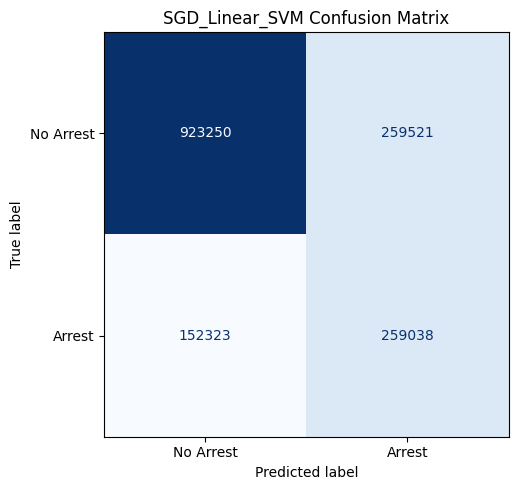

In [22]:
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV

# Base SGD Classifier
sgd = SGDClassifier(
    loss='hinge',
    penalty='l2',
    alpha=0.0001,
    max_iter=1000,
    tol=1e-3,
    random_state=42,
    n_jobs=-1
)

# Calibrate to obtain probability estimates
sgd_model = CalibratedClassifierCV(
    estimator=sgd,
    method='sigmoid',
    cv=5
)

sgd_results = evaluate_model(
    model=sgd_model,
    model_name="SGD_Linear_SVM",
    X_train=X_train_scaled,
    y_train=y_train_under,
    X_test=X_test_scaled,
    y_test=y_test
)

# MLP Classifier

Iteration 1, loss = 0.42531155
Validation score: 0.807544
Iteration 2, loss = 0.39509148
Validation score: 0.810595
Iteration 3, loss = 0.39143639
Validation score: 0.810668
Iteration 4, loss = 0.38944324
Validation score: 0.812425
Iteration 5, loss = 0.38784470
Validation score: 0.814360
Iteration 6, loss = 0.38675974
Validation score: 0.813169
Iteration 7, loss = 0.38595591
Validation score: 0.814008
Iteration 8, loss = 0.38537170
Validation score: 0.814187
Iteration 9, loss = 0.38487693
Validation score: 0.814758
Iteration 10, loss = 0.38425945
Validation score: 0.815007
Iteration 11, loss = 0.38380928
Validation score: 0.815038
Iteration 12, loss = 0.38356025
Validation score: 0.815962
Iteration 13, loss = 0.38315592
Validation score: 0.815703
Iteration 14, loss = 0.38273573
Validation score: 0.816047
Iteration 15, loss = 0.38255945
Validation score: 0.813983
Iteration 16, loss = 0.38240255
Validation score: 0.815266
Iteration 17, loss = 0.38222417
Validation score: 0.816035
Iterat

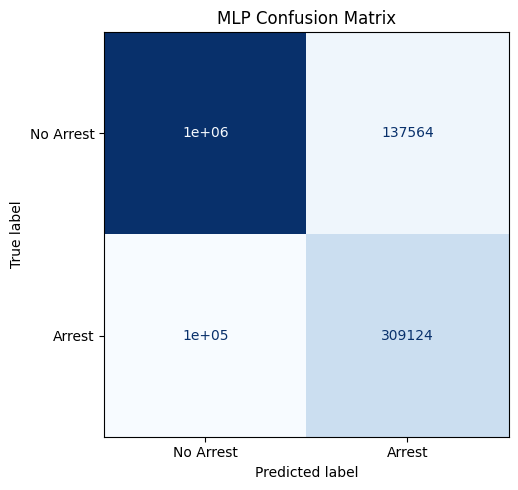

In [23]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    max_iter=100,
    shuffle=True,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=True
)

mlp_results = evaluate_model(
    model=mlp_model,
    model_name="MLP",
    X_train=X_train_scaled,         # Used scaled data
    y_train=y_train_under,
    X_test=X_test_scaled,
    y_test=y_test
)

# LSTM

In [24]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [25]:
# Reshape data for LSTM
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0],1,X_train_scaled.shape[1])
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0],1,X_test_scaled.shape[1])

print(X_train_lstm.shape)
print(X_test_lstm.shape)

(3290888, 1, 27)
(1594132, 1, 27)


In [26]:
# LSTM model

lstm_model = Sequential([

    LSTM(64,input_shape=(1, X_train_lstm.shape[2])),
    Dropout(0.3),
    Dense(32,activation='relu'),
    Dense(1,activation='sigmoid')

])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        23,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,665 (100.25 KB)

 Trainable params: 25,665 (100.25 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Train LSTM
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

start_time = time.time()

history = lstm_model.fit(
    X_train_lstm,
    y_train_under,
    validation_split=0.1,
    epochs=20,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining Time : {training_time:.2f} seconds")

Epoch 1/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8006 - loss: 0.4334 - val_accuracy: 0.6583 - val_loss: 0.5095
Epoch 2/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8167 - loss: 0.3977 - val_accuracy: 0.6819 - val_loss: 0.4835
Epoch 3/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8198 - loss: 0.3906 - val_accuracy: 0.6777 - val_loss: 0.4950
Epoch 4/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8212 - loss: 0.3871 - val_accuracy: 0.6953 - val_loss: 0.4626
Epoch 5/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8222 - loss: 0.3845 - val_accuracy: 0.6881 - val_loss: 0.4781
Epoch 6/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8231 - loss: 0.3825 - val_accuracy: 0.6913 - val_loss: 0.4651
Epoch 7/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8236 - loss: 0.3812 - val_accuracy: 0.6867 - val_loss: 0.4786

Training Time : 62.38 seconds


In [28]:
# Deep Learning Model Evaluation Function

def evaluate_deep_learning_model(
    model,
    model_name,
    y_true,
    y_pred,
    y_prob,
    training_time,
    model_folder=MODEL_FOLDER,
    result_folder=RESULT_FOLDER
):
    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    print(f"\nTraining Time : {training_time:.2f} seconds")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")
    print(f"PR AUC    : {pr_auc:.4f}")

    # Classification Report
    report = classification_report(y_true,y_pred,output_dict=True)
    print(classification_report(y_true, y_pred))
    report_df = pd.DataFrame(report).transpose()
    report_path = os.path.join(result_folder,f"{model_name}_Classification_Report.csv")
    report_df.to_csv(report_path)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm,index=["Actual_0","Actual_1"],columns=["Predicted_0","Predicted_1"])
    cm_path = os.path.join(result_folder,f"{model_name}_Confusion_Matrix.csv")
    cm_df.to_csv(cm_path)

    # Plot
    fig, ax = plt.subplots(figsize=(6,5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Arrest","Arrest"])
    disp.plot(cmap="Blues",ax=ax,colorbar=False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    figure_path = os.path.join(result_folder,f"{model_name}_Confusion_Matrix.png")
    plt.savefig(figure_path,dpi=300,bbox_inches="tight")
    plt.show()

    # Save Model
    model_path = os.path.join(model_folder,f"{model_name}.keras")
    model.save(model_path)

    # Store Results
    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc,
        "Training Time (s)": round(training_time, 2)
    }
    all_results.append(results)

    return results

1557/1557 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Training Time : 62.38 seconds
Accuracy  : 0.8680
Precision : 0.7702
Recall    : 0.6960
F1 Score  : 0.7312
ROC AUC   : 0.8981
PR AUC    : 0.8335
              precision    recall  f1-score   support

           0       0.90      0.93      0.91   1182771
           1       0.77      0.70      0.73    411361

    accuracy                           0.87   1594132
   macro avg       0.83      0.81      0.82   1594132
weighted avg       0.86      0.87      0.87   1594132



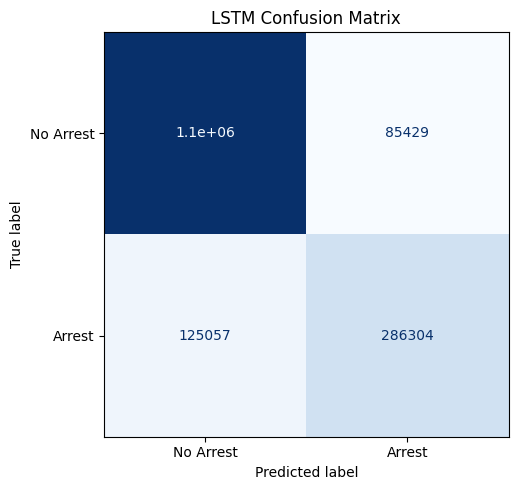

In [29]:
# Prediction

y_prob = lstm_model.predict( X_test_lstm,batch_size=1024)
y_prob = y_prob.ravel()
y_pred = (y_prob >= 0.5).astype(int)

lstm_results = evaluate_deep_learning_model(
    model=lstm_model,
    model_name="LSTM",
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    training_time=training_time
)

# GRU

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

gru_model = Sequential([
    GRU(units=64,input_shape=(1, X_train_lstm.shape[2])),
    Dropout(0.3),
    Dense(units=32,activation='relu'),
    Dense(units=1,activation='sigmoid')
])

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        17,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,969 (78.00 KB)

 Trainable params: 19,969 (78.00 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:

# Train GRU
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

start_time = time.time()
history = gru_model.fit(
    X_train_lstm,
    y_train_under,
    validation_split=0.1,
    epochs=20,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining Time : {training_time:.2f} seconds")

Epoch 1/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8001 - loss: 0.4355 - val_accuracy: 0.6591 - val_loss: 0.5000
Epoch 2/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8162 - loss: 0.3981 - val_accuracy: 0.6804 - val_loss: 0.4759
Epoch 3/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8194 - loss: 0.3918 - val_accuracy: 0.6757 - val_loss: 0.4856
Epoch 4/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8207 - loss: 0.3886 - val_accuracy: 0.6792 - val_loss: 0.4884
Epoch 5/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8217 - loss: 0.3863 - val_accuracy: 0.6788 - val_loss: 0.4930

Training Time : 57.56 seconds


1557/1557 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

Training Time : 57.56 seconds
Accuracy  : 0.8692
Precision : 0.7835
Recall    : 0.6817
F1 Score  : 0.7290
ROC AUC   : 0.8939
PR AUC    : 0.8271
              precision    recall  f1-score   support

           0       0.89      0.93      0.91   1182771
           1       0.78      0.68      0.73    411361

    accuracy                           0.87   1594132
   macro avg       0.84      0.81      0.82   1594132
weighted avg       0.87      0.87      0.87   1594132



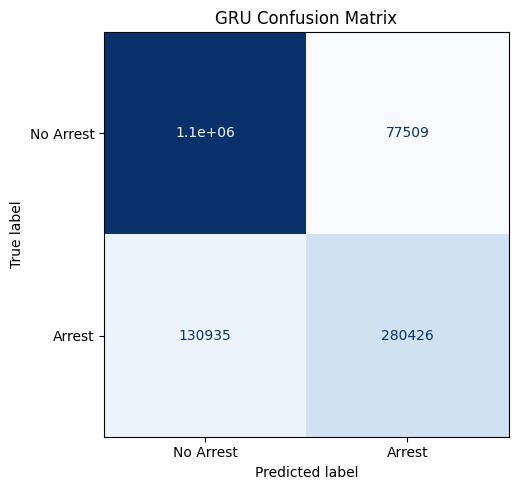

In [32]:
# Evaluate GRU

y_prob = gru_model.predict(X_test_lstm,batch_size=1024)
y_prob = y_prob.ravel()
y_pred = (y_prob >= 0.5).astype(int)

gru_results = evaluate_deep_learning_model(
    model=gru_model,
    model_name="GRU",
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    training_time=training_time
)

# TCN

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tcn import TCN

In [34]:
# Build TCN Model
tcn_model = Sequential([
    TCN(nb_filters=64,kernel_size=3, dilations=[1, 2, 4, 8],dropout_rate=0.3,input_shape=(1, X_train_lstm.shape[2])),
    Dense(32,activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')
])

tcn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

tcn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn (TCN)                       │ (None, 64)             │        93,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,617 (373.50 KB)

 Trainable params: 95,617 (373.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Train TCN

early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

start_time = time.time()
history = tcn_model.fit(
    X_train_lstm,
    y_train_under,
    validation_split=0.1,
    epochs=20,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining Time : {training_time:.2f} seconds")

Epoch 1/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 112s 37ms/step - accuracy: 0.8002 - loss: 0.4339 - val_accuracy: 0.6609 - val_loss: 0.4707
Epoch 2/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.8192 - loss: 0.3930 - val_accuracy: 0.6689 - val_loss: 0.4719
Epoch 3/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 107s 37ms/step - accuracy: 0.8223 - loss: 0.3851 - val_accuracy: 0.6760 - val_loss: 0.4677
Epoch 4/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 104s 36ms/step - accuracy: 0.8241 - loss: 0.3815 - val_accuracy: 0.6859 - val_loss: 0.4657
Epoch 5/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 107s 37ms/step - accuracy: 0.8256 - loss: 0.3790 - val_accuracy: 0.6861 - val_loss: 0.4646
Epoch 6/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 107s 37ms/step - accuracy: 0.8263 - loss: 0.3775 - val_accuracy: 0.6939 - val_loss: 0.4540
Epoch 7/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 107s 37ms/step - accuracy: 0.8269 - loss: 0.3764 - val_accuracy: 0.6937 - val_loss: 0.4584
Epoch 8/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 107s 37ms/step - accuracy: 0

1557/1557 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step

Training Time : 940.99 seconds
Accuracy  : 0.8750
Precision : 0.7950
Recall    : 0.6950
F1 Score  : 0.7416
ROC AUC   : 0.9033
PR AUC    : 0.8424
              precision    recall  f1-score   support

           0       0.90      0.94      0.92   1182771
           1       0.79      0.70      0.74    411361

    accuracy                           0.88   1594132
   macro avg       0.85      0.82      0.83   1594132
weighted avg       0.87      0.88      0.87   1594132



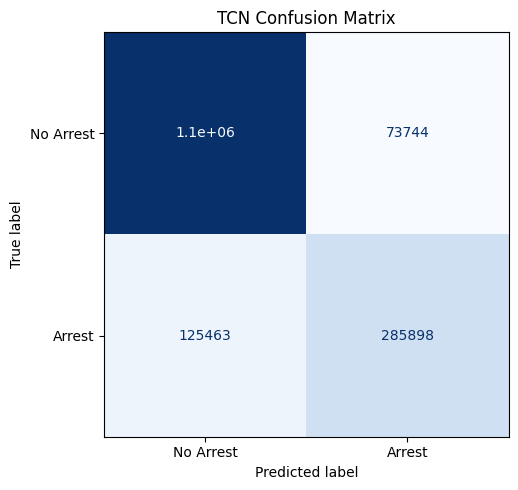

In [36]:
# Evaluate TCN
y_prob = tcn_model.predict(X_test_lstm,batch_size=1024)
y_prob = y_prob.ravel()
y_pred = (y_prob >= 0.5).astype(int)

tcn_results = evaluate_deep_learning_model(
    model=tcn_model,
    model_name="TCN",
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    training_time=training_time
)

# Print all results


In [ ]:
results_df = pd.DataFrame(all_results)
print("All Model Results")
print(results_df)

All Model Results
                  Model  Accuracy  Precision    Recall  F1 Score   ROC AUC  \
0   Logistic_Regression  0.747949   0.509240  0.640258  0.567282  0.754625   
1         Decision_Tree  0.769813   0.537188  0.779797  0.636146  0.773108   
2         Random_Forest  0.860433   0.714003  0.765940  0.739060  0.913332   
3           Extra_Trees  0.853321   0.696923  0.763694  0.728782  0.907003   
4     Gradient_Boosting  0.862796   0.740894  0.720151  0.730375  0.898998   
5              AdaBoost  0.832631   0.672111  0.686130  0.679048  0.874309   
6               XGBoost  0.864028   0.731296  0.747861  0.739486  0.911287   
7              LightGBM  0.862984   0.728392  0.747912  0.738023  0.910862   
8              CatBoost  0.862424   0.731847  0.736839  0.734335  0.905379   
9            Linear_SVM  0.747808   0.509026  0.639745  0.566948  0.753929   
10       SGD_Linear_SVM  0.741650   0.499534  0.629710  0.557119  0.738930   
11                  MLP  0.849573   0.692036  

In [ ]:
results_df.to_csv( r'1. Under_Sampling_Results\All_Model_Results.csv', index=False)

In [ ]:
# Sort by f1 score
results_df = results_df.sort_values( by="F1 Score", ascending=False).reset_index(drop=True)
print(results_df)

                  Model  Accuracy  Precision    Recall  F1 Score   ROC AUC  \
0                   TCN  0.875037   0.794952  0.695005  0.741626  0.903264   
1               XGBoost  0.864028   0.731296  0.747861  0.739486  0.911287   
2         Random_Forest  0.860433   0.714003  0.765940  0.739060  0.913332   
3              LightGBM  0.862984   0.728392  0.747912  0.738023  0.910862   
4              CatBoost  0.862424   0.731847  0.736839  0.734335  0.905379   
5                  LSTM  0.867962   0.770187  0.695992  0.731212  0.898108   
6     Gradient_Boosting  0.862796   0.740894  0.720151  0.730375  0.898998   
7                   GRU  0.869243   0.783455  0.681703  0.729046  0.893899   
8           Extra_Trees  0.853321   0.696923  0.763694  0.728782  0.907003   
9                   MLP  0.849573   0.692036  0.751466  0.720528  0.901314   
10             AdaBoost  0.832631   0.672111  0.686130  0.679048  0.874309   
11        Decision_Tree  0.769813   0.537188  0.779797  0.636146

In [ ]:
results_df.to_csv( r'1. Under_Sampling_Results\All_Model_Results_Sorted.csv', index=False)

In [41]:
print("\nTop 5 Models Based on F1 Score\n")

print(
    results_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC AUC",
            "PR AUC"
        ]
    ].head()
)


Top 5 Models Based on F1 Score

           Model  Accuracy  Precision    Recall  F1 Score   ROC AUC    PR AUC
0            TCN  0.875037   0.794952  0.695005  0.741626  0.903264  0.842440
1        XGBoost  0.864028   0.731296  0.747861  0.739486  0.911287  0.852707
2  Random_Forest  0.860433   0.714003  0.765940  0.739060  0.913332  0.854524
3       LightGBM  0.862984   0.728392  0.747912  0.738023  0.910862  0.851952
4       CatBoost  0.862424   0.731847  0.736839  0.734335  0.905379  0.844035


In [ ]:
results_df.insert( 0, "Rank", range(1, len(results_df) + 1))
print(results_df)

    Rank                Model  Accuracy  Precision    Recall  F1 Score  \
0      1                  TCN  0.875037   0.794952  0.695005  0.741626   
1      2              XGBoost  0.864028   0.731296  0.747861  0.739486   
2      3        Random_Forest  0.860433   0.714003  0.765940  0.739060   
3      4             LightGBM  0.862984   0.728392  0.747912  0.738023   
4      5             CatBoost  0.862424   0.731847  0.736839  0.734335   
5      6                 LSTM  0.867962   0.770187  0.695992  0.731212   
6      7    Gradient_Boosting  0.862796   0.740894  0.720151  0.730375   
7      8                  GRU  0.869243   0.783455  0.681703  0.729046   
8      9          Extra_Trees  0.853321   0.696923  0.763694  0.728782   
9     10                  MLP  0.849573   0.692036  0.751466  0.720528   
10    11             AdaBoost  0.832631   0.672111  0.686130  0.679048   
11    12        Decision_Tree  0.769813   0.537188  0.779797  0.636146   
12    13  Logistic_Regression  0.74794